In [1]:
import numpy as np 
import pandas as pd 
import math
import random
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn import metrics
from sklearn import svm
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.dummy import DummyClassifier
from imblearn.metrics import geometric_mean_score

In [2]:
data=pd.read_csv("car.csv")

In [3]:
import sklearn
sklearn.__version__

'1.0.2'

In [4]:
data.columns=["id","buying", "Oxin","Onine","Hormone","Tsh","Resin","Class"]

In [5]:
data.set_index("id", inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1727 entries, 1 to 1727
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   buying   1727 non-null   object
 1   Oxin     1727 non-null   object
 2   Onine    1727 non-null   object
 3   Hormone  1727 non-null   object
 4   Tsh      1727 non-null   object
 5   Resin    1727 non-null   object
 6   Class    1727 non-null   object
dtypes: object(7)
memory usage: 107.9+ KB


In [7]:
data.Class = pd.factorize(data.Class)[0] + 1

In [8]:
data.buying = pd.factorize(data.buying)[0] + 1

In [9]:
data.Oxin = pd.factorize(data.Oxin)[0] + 1

In [10]:
data.Onine = pd.factorize(data.Onine)[0] + 1

In [11]:
data.Hormone = pd.factorize(data.Hormone)[0] + 1

In [12]:
data.Tsh = pd.factorize(data.Tsh)[0] + 1

In [13]:
data.Resin = pd.factorize(data.Resin)[0] + 1

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1727 entries, 1 to 1727
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   buying   1727 non-null   int64
 1   Oxin     1727 non-null   int64
 2   Onine    1727 non-null   int64
 3   Hormone  1727 non-null   int64
 4   Tsh      1727 non-null   int64
 5   Resin    1727 non-null   int64
 6   Class    1727 non-null   int64
dtypes: int64(7)
memory usage: 107.9 KB


In [15]:
gb=data.groupby("Class")

In [16]:
for Class, Class_df in gb:
    print(Class)
    print(Class_df)

1
      buying  Oxin  Onine  Hormone  Tsh  Resin  Class
id                                                   
1          1     1      1        1    1      1      1
2          1     1      1        1    1      2      1
3          1     1      1        1    2      3      1
4          1     1      1        1    2      1      1
5          1     1      1        1    2      2      1
...      ...   ...    ...      ...  ...    ...    ...
1713       4     4      4        2    2      3      1
1716       4     4      4        2    3      3      1
1719       4     4      4        3    1      3      1
1722       4     4      4        3    2      3      1
1725       4     4      4        3    3      3      1

[1209 rows x 7 columns]
2
      buying  Oxin  Onine  Hormone  Tsh  Resin  Class
id                                                   
227        1     3      1        2    1      2      2
230        1     3      1        2    2      2      2
232        1     3      1        2    3      1      2

In [17]:
gb.get_group(1)

,buying,Oxin,Onine,Hormone,Tsh,Resin,Class
id,,,,,,,
1,1,1,1,1,1,1,1
2,1,1,1,1,1,2,1
3,1,1,1,1,2,3,1
4,1,1,1,1,2,1,1
5,1,1,1,1,2,2,1
...,...,...,...,...,...,...,...
1713,4,4,4,2,2,3,1
1716,4,4,4,2,3,3,1
1719,4,4,4,3,1,3,1


In [18]:
class_samples=gb.get_group(1).sample(n=15)
#    print(class_samples)

In [19]:
print(type(class_samples))

<class 'pandas.core.frame.DataFrame'>


In [20]:
mean_sum=class_samples["buying"].mean() + class_samples["Oxin"].mean() + class_samples["Onine"].mean() + class_samples["Hormone"].mean() + class_samples["Tsh"].mean() + class_samples["Resin"].mean()

In [21]:
column_length=len(data.columns) -1

In [22]:
similar_val_1=mean_sum/column_length
print(similar_val_1)

2.1777777777777776


In [23]:
class_2_samples=gb.get_group(2).sample(n=15)
#    print(class_2_samples)

In [24]:
mean_sum_2=class_2_samples["buying"].mean() + class_2_samples["Oxin"].mean() + class_2_samples["Onine"].mean() + class_2_samples["Hormone"].mean() + class_2_samples["Tsh"].mean() + class_2_samples["Resin"].mean()

In [25]:
similar_val_2=mean_sum_2/column_length
print(similar_val_2)

2.3


In [26]:
class_3_samples=gb.get_group(3).sample(n=15)
#    print(class_3_samples)

In [27]:
mean_sum_3=class_3_samples["buying"].mean() + class_3_samples["Oxin"].mean() + class_3_samples["Onine"].mean() + class_3_samples["Hormone"].mean() + class_3_samples["Tsh"].mean() + class_3_samples["Resin"].mean()

In [28]:
similar_val_3=mean_sum_3/column_length
print(similar_val_3)

2.8111111111111113


In [29]:
class_4_samples=gb.get_group(4).sample(n=15)
#    print(class_3_samples)

In [30]:
mean_sum_4=class_4_samples["buying"].mean() + class_4_samples["Oxin"].mean() + class_4_samples["Onine"].mean() + class_4_samples["Hormone"].mean() + class_4_samples["Tsh"].mean() + class_4_samples["Resin"].mean()

In [31]:
similar_val_4=mean_sum_4/column_length
print(similar_val_4)

2.711111111111111


In [32]:
sim_12=similar_val_1 - similar_val_2
sim_12=sim_12/100
sim_12=1 - sim_12
sim_13=similar_val_3 - similar_val_1
sim_13=sim_13/100
sim_13=1 - sim_13
sim_14=similar_val_4 - similar_val_1
sim_14=sim_14/100
sim_14=1 - sim_14
sim_23=similar_val_3 - similar_val_2
sim_23=sim_23/100
sim_23=1 - sim_23
sim_24=similar_val_4 - similar_val_2
sim_24=sim_24/100
sim_24=1 - sim_24
sim_34=similar_val_4 - similar_val_3
sim_34=sim_34/100
sim_34=1 - sim_34


print("Similarity between 1 and 2: ", sim_12)
print("Similarity between 1 and 3: ", sim_13)
print("Similarity between 1 and 4: ", sim_14)
print("Similarity between 2 and 3: ", sim_23)
print("Similarity between 2 and 4: ", sim_24)
print("Similarity between 3 and 4: ", sim_34)

Similarity between 1 and 2:  1.0012222222222222
Similarity between 1 and 3:  0.9936666666666667
Similarity between 1 and 4:  0.9946666666666667
Similarity between 2 and 3:  0.9948888888888889
Similarity between 2 and 4:  0.9958888888888889
Similarity between 3 and 4:  1.0010000000000001


In [33]:
gb.size()

Class
1    1209
2     384
3      65
4      69
dtype: int64

In [34]:
m=math.ceil((1209+384)/2)

In [35]:
print(m)

797


In [36]:
len(gb)

4

In [37]:
neigh = KNeighborsClassifier(n_neighbors=5)

In [38]:
#neigh.fit(X_train, Y_train)
neigh.fit(data, data.Class)

KNeighborsClassifier()

In [39]:
result=neigh.kneighbors(data, return_distance=True)

In [40]:
print(type(result))

<class 'tuple'>


In [41]:
print(result)

(array([[0., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1.],
       ...,
       [0., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1.],
       [0., 1., 1., 1., 1.]]), array([[   0,    1,  108,  432,    9],
       [   1,  109,  433,    0,   10],
       [   2,    4,   29,  110,   11],
       ...,
       [1724, 1697, 1292, 1715, 1616],
       [1725, 1698, 1716, 1617, 1293],
       [1726, 1618, 1717, 1699, 1294]], dtype=int64))


In [42]:
arr1=result[0]

In [43]:
print(type(arr1))

<class 'numpy.ndarray'>


In [44]:
print(arr1.ndim)

2


In [45]:
arr2=result[1]

In [46]:
print(type(arr2))

<class 'numpy.ndarray'>


In [47]:
print(arr1.ndim)

2


In [48]:
print(arr2)

[[   0    1  108  432    9]
 [   1  109  433    0   10]
 [   2    4   29  110   11]
 ...
 [1724 1697 1292 1715 1616]
 [1725 1698 1716 1617 1293]
 [1726 1618 1717 1699 1294]]


In [49]:
print(arr1)

[[0. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 ...
 [0. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]
 [0. 1. 1. 1. 1.]]


In [50]:
#print(arr1)

In [51]:
print(arr1.size)

8635


In [52]:
addVal=[]
s=1
for i in arr1:
    _sum=int(i[0] + i[1] + i[2] + i[3] + i[4])
    addVal.append(_sum)
    print(i ," ", _sum, " ") 
    s=s+1

[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1

[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1

[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1

[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.41421356]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0.         1.         1.         1.         1.41421356]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  
[0. 1. 1. 1. 1.]   4  


In [53]:
print(len(addVal))

1727


In [54]:
print(addVal)

[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 

In [55]:
arr3=np.array(addVal)

In [56]:
print(type(arr3))

<class 'numpy.ndarray'>


In [57]:
print(arr3.size)

1727


In [58]:
print(arr3)

[4 4 4 ... 4 4 4]


In [59]:
g=1
for i in addVal:
    print(g ," ", i) 
    g=g+1

1   4
2   4
3   4
4   4
5   4
6   4
7   4
8   4
9   4
10   4
11   4
12   4
13   4
14   4
15   4
16   4
17   4
18   4
19   4
20   4
21   4
22   4
23   4
24   4
25   4
26   4
27   4
28   4
29   4
30   4
31   4
32   4
33   4
34   4
35   4
36   4
37   4
38   4
39   4
40   4
41   4
42   4
43   4
44   4
45   4
46   4
47   4
48   4
49   4
50   4
51   4
52   4
53   4
54   4
55   4
56   4
57   4
58   4
59   4
60   4
61   4
62   4
63   4
64   4
65   4
66   4
67   4
68   4
69   4
70   4
71   4
72   4
73   4
74   4
75   4
76   4
77   4
78   4
79   4
80   4
81   4
82   4
83   4
84   4
85   4
86   4
87   4
88   4
89   4
90   4
91   4
92   4
93   4
94   4
95   4
96   4
97   4
98   4
99   4
100   4
101   4
102   4
103   4
104   4
105   4
106   4
107   4
108   4
109   4
110   4
111   4
112   4
113   4
114   4
115   4
116   4
117   4
118   4
119   4
120   4
121   4
122   4
123   4
124   4
125   4
126   4
127   4
128   4
129   4
130   4
131   4
132   4
133   4
134   4
135   4
136   4
137   4
138   4
139 

1265   4
1266   4
1267   4
1268   4
1269   4
1270   4
1271   4
1272   4
1273   4
1274   4
1275   4
1276   4
1277   4
1278   4
1279   4
1280   4
1281   4
1282   4
1283   4
1284   4
1285   4
1286   4
1287   4
1288   4
1289   4
1290   4
1291   4
1292   4
1293   4
1294   4
1295   4
1296   4
1297   4
1298   4
1299   4
1300   4
1301   4
1302   4
1303   4
1304   4
1305   4
1306   4
1307   4
1308   4
1309   4
1310   4
1311   4
1312   4
1313   4
1314   4
1315   4
1316   4
1317   4
1318   4
1319   4
1320   4
1321   4
1322   4
1323   4
1324   4
1325   4
1326   4
1327   4
1328   4
1329   4
1330   4
1331   4
1332   4
1333   4
1334   4
1335   4
1336   4
1337   4
1338   4
1339   4
1340   4
1341   4
1342   4
1343   4
1344   4
1345   4
1346   4
1347   4
1348   4
1349   4
1350   4
1351   4
1352   4
1353   4
1354   4
1355   4
1356   4
1357   4
1358   4
1359   4
1360   4
1361   4
1362   4
1363   4
1364   4
1365   4
1366   4
1367   4
1368   4
1369   4
1370   4
1371   4
1372   4
1373   4
1374   4
1375   4
1

In [60]:
newarr = arr3.reshape(1727, 1)

In [61]:
print(newarr.ndim)

2


In [62]:
new_arr2=np.append(arr2, newarr, axis=1)

In [63]:
print(type(new_arr2))

<class 'numpy.ndarray'>


In [64]:
print(new_arr2)

[[   0    1  108  432    9    4]
 [   1  109  433    0   10    4]
 [   2    4   29  110   11    4]
 ...
 [1724 1697 1292 1715 1616    4]
 [1725 1698 1716 1617 1293    4]
 [1726 1618 1717 1699 1294    4]]


In [65]:
print(new_arr2[0])

[  0   1 108 432   9   4]


In [66]:
arr2

array([[   0,    1,  108,  432,    9],
       [   1,  109,  433,    0,   10],
       [   2,    4,   29,  110,   11],
       ...,
       [1724, 1697, 1292, 1715, 1616],
       [1725, 1698, 1716, 1617, 1293],
       [1726, 1618, 1717, 1699, 1294]], dtype=int64)

In [67]:
print(new_arr2[0][1],  new_arr2[0][2],  new_arr2[0][3], new_arr2[0][4],new_arr2[0][5])

1 108 432 9 4


In [68]:
# Creating and populating a dictionary
new_dist={}
for i, v in data.Class.iteritems():
    new_dist[i]=v

In [69]:
print(new_dist)

{1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 132: 1, 133: 1, 134: 1, 135: 1, 136: 1, 137: 1, 138: 1, 139

In [70]:
# Creating and populating a dictionary
new_dist2={}
s=0
for i, v in data.Class.iteritems():
    new_dist2[s]=v
    s=s+1

In [71]:
print(new_dist2)

{0: 1, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 1, 14: 1, 15: 1, 16: 1, 17: 1, 18: 1, 19: 1, 20: 1, 21: 1, 22: 1, 23: 1, 24: 1, 25: 1, 26: 1, 27: 1, 28: 1, 29: 1, 30: 1, 31: 1, 32: 1, 33: 1, 34: 1, 35: 1, 36: 1, 37: 1, 38: 1, 39: 1, 40: 1, 41: 1, 42: 1, 43: 1, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1, 52: 1, 53: 1, 54: 1, 55: 1, 56: 1, 57: 1, 58: 1, 59: 1, 60: 1, 61: 1, 62: 1, 63: 1, 64: 1, 65: 1, 66: 1, 67: 1, 68: 1, 69: 1, 70: 1, 71: 1, 72: 1, 73: 1, 74: 1, 75: 1, 76: 1, 77: 1, 78: 1, 79: 1, 80: 1, 81: 1, 82: 1, 83: 1, 84: 1, 85: 1, 86: 1, 87: 1, 88: 1, 89: 1, 90: 1, 91: 1, 92: 1, 93: 1, 94: 1, 95: 1, 96: 1, 97: 1, 98: 1, 99: 1, 100: 1, 101: 1, 102: 1, 103: 1, 104: 1, 105: 1, 106: 1, 107: 1, 108: 1, 109: 1, 110: 1, 111: 1, 112: 1, 113: 1, 114: 1, 115: 1, 116: 1, 117: 1, 118: 1, 119: 1, 120: 1, 121: 1, 122: 1, 123: 1, 124: 1, 125: 1, 126: 1, 127: 1, 128: 1, 129: 1, 130: 1, 131: 1, 132: 1, 133: 1, 134: 1, 135: 1, 136: 1, 137: 1, 138: 

In [72]:
# Creating and populating a dictionary
new_dist3={}
s=0
for i, v in data.Class.iteritems():
    new_dist3[s]=i
    s=s+1

In [73]:
print(new_dist3)

{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 30, 30: 31, 31: 32, 32: 33, 33: 34, 34: 35, 35: 36, 36: 37, 37: 38, 38: 39, 39: 40, 40: 41, 41: 42, 42: 43, 43: 44, 44: 45, 45: 46, 46: 47, 47: 48, 48: 49, 49: 50, 50: 51, 51: 52, 52: 53, 53: 54, 54: 55, 55: 56, 56: 57, 57: 58, 58: 59, 59: 60, 60: 61, 61: 62, 62: 63, 63: 64, 64: 65, 65: 66, 66: 67, 67: 68, 68: 69, 69: 70, 70: 71, 71: 72, 72: 73, 73: 74, 74: 75, 75: 76, 76: 77, 77: 78, 78: 79, 79: 80, 80: 81, 81: 82, 82: 83, 83: 84, 84: 85, 85: 86, 86: 87, 87: 88, 88: 89, 89: 90, 90: 91, 91: 92, 92: 93, 93: 94, 94: 95, 95: 96, 96: 97, 97: 98, 98: 99, 99: 100, 100: 101, 101: 102, 102: 103, 103: 104, 104: 105, 105: 106, 106: 107, 107: 108, 108: 109, 109: 110, 110: 111, 111: 112, 112: 113, 113: 114, 114: 115, 115: 116, 116: 117, 117: 118, 118: 119, 119: 120, 120: 121, 121: 12

In [74]:
#print(new_dist[204])

<!-- Populating a dictionary  -->

In [75]:
    neigh_count=[]
    s=0
    for i, v in new_dist2.items():
        c1=0
        c2=0
        c3=0
        c4=0
        class_example=0
        if int(v) == 1:
            c1=c1+1
        elif int(v) == 2:
            c2=c2+1
        elif int(v) == 3:
            c3=c3+1
        else:
            c4=c4+1
        for x in range(1,5):
            if new_dist2[new_arr2[i][x]]==1:
                c1=c1+1
            elif new_dist2[new_arr2[i][x]]==2:
                c2=c2+1
            elif new_dist2[new_arr2[i][x]]==3:
                c3=c3+1
            else:
                c4=c4+1
            if int(v) == 1:
                safe_level=(1 * c1 + sim_12 * c2 + sim_13 * c3+ sim_14 * c4)/5
                class_example=1
                safe_level=round(safe_level,2)
            elif int(v) == 2:
                safe_level=(sim_12 * c1 + 1 * c2 + sim_23 * c3+ sim_24 * c4)/5
                class_example=2
                safe_level=round(safe_level,2)
            elif int(v) == 3:
                safe_level=(sim_13 * c1 + sim_23 * c2 + 1 * c3 + sim_34 * c4)/5
                class_example=3
                safe_level=round(safe_level,2)
            else:
                safe_level=(sim_14* c1 + sim_24 * c2 + sim_34 * c3 + 1 * c4)/5
                class_example=4
                safe_level=round(safe_level,2)
        neigh_count.append([i,new_dist3[i],class_example,c1,c2,c3,c4,safe_level,new_arr2[i][5]])
        #print(i," ",new_dist3[i]," ",class_example," ",c1," ",c2," ",c3," ",safe_level," ",new_arr2[i][5])
        #print(i," ",new_dist3[i]," ",c1," ",c2," ",c3," ",new_arr2[i][5])
    #real_new=new_dist3[i]," ",new_arr2[i][1]," ",new_arr2[i][2]," ",new_arr2[i][3]," ",new_arr2[i][4]," ",new_arr2[i][5]
    
    #print(i," ",real_new)

In [76]:
#print(neigh_count)

In [77]:
# iterating a dictionary

In [78]:
# for s in range(149):
#     print(neigh_count[s])

In [79]:
# Converting a dictionary to a dataframe

In [80]:
new_main_df = pd.DataFrame(neigh_count,columns=['s_no','real_index','Class','c_one','c_two','c_three','c_four','safe_level','distance'])

In [81]:
#print(new_main_df)

In [82]:
new_main_df.set_index("s_no", inplace=True)

In [83]:
print(new_main_df)

      real_index  Class  c_one  c_two  c_three  c_four  safe_level  distance
s_no                                                                        
0              1      1      5      0        0       0         1.0         4
1              2      1      5      0        0       0         1.0         4
2              3      1      5      0        0       0         1.0         4
3              4      1      5      0        0       0         1.0         4
4              5      1      5      0        0       0         1.0         4
...          ...    ...    ...    ...      ...     ...         ...       ...
1722        1723      4      0      0        0       5         1.0         4
1723        1724      3      0      0        5       0         1.0         4
1724        1725      1      5      0        0       0         1.0         4
1725        1726      4      0      0        0       5         1.0         4
1726        1727      3      0      0        5       0         1.0         4

In [84]:
# iterating through a dataframe, the following methods can be used .iterrows() 
# and itertuples() but itertuples is preferred because it keeps the data types and more

In [85]:
# for index, row in new_main_df.iterrows():
#     print(index, row['real_index'], row['class'], row['c_one'], row['c_two'], row['c_three'], row['safe_level'], row['distance'] )

In [86]:
for i, row in enumerate(new_main_df.itertuples(), 0):
    print(i, row.real_index)
    

0 1
1 2
2 3
3 4
4 5
5 6
6 7
7 8
8 9
9 10
10 11
11 12
12 13
13 14
14 15
15 16
16 17
17 18
18 19
19 20
20 21
21 22
22 23
23 24
24 25
25 26
26 27
27 28
28 29
29 30
30 31
31 32
32 33
33 34
34 35
35 36
36 37
37 38
38 39
39 40
40 41
41 42
42 43
43 44
44 45
45 46
46 47
47 48
48 49
49 50
50 51
51 52
52 53
53 54
54 55
55 56
56 57
57 58
58 59
59 60
60 61
61 62
62 63
63 64
64 65
65 66
66 67
67 68
68 69
69 70
70 71
71 72
72 73
73 74
74 75
75 76
76 77
77 78
78 79
79 80
80 81
81 82
82 83
83 84
84 85
85 86
86 87
87 88
88 89
89 90
90 91
91 92
92 93
93 94
94 95
95 96
96 97
97 98
98 99
99 100
100 101
101 102
102 103
103 104
104 105
105 106
106 107
107 108
108 109
109 110
110 111
111 112
112 113
113 114
114 115
115 116
116 117
117 118
118 119
119 120
120 121
121 122
122 123
123 124
124 125
125 126
126 127
127 128
128 129
129 130
130 131
131 132
132 133
133 134
134 135
135 136
136 137
137 138
138 139
139 140
140 141
141 142
142 143
143 144
144 145
145 146
146 147
147 148
148 149
149 150
150 151
151 152
15

1409 1410
1410 1411
1411 1412
1412 1413
1413 1414
1414 1415
1415 1416
1416 1417
1417 1418
1418 1419
1419 1420
1420 1421
1421 1422
1422 1423
1423 1424
1424 1425
1425 1426
1426 1427
1427 1428
1428 1429
1429 1430
1430 1431
1431 1432
1432 1433
1433 1434
1434 1435
1435 1436
1436 1437
1437 1438
1438 1439
1439 1440
1440 1441
1441 1442
1442 1443
1443 1444
1444 1445
1445 1446
1446 1447
1447 1448
1448 1449
1449 1450
1450 1451
1451 1452
1452 1453
1453 1454
1454 1455
1455 1456
1456 1457
1457 1458
1458 1459
1459 1460
1460 1461
1461 1462
1462 1463
1463 1464
1464 1465
1465 1466
1466 1467
1467 1468
1468 1469
1469 1470
1470 1471
1471 1472
1472 1473
1473 1474
1474 1475
1475 1476
1476 1477
1477 1478
1478 1479
1479 1480
1480 1481
1481 1482
1482 1483
1483 1484
1484 1485
1485 1486
1486 1487
1487 1488
1488 1489
1489 1490
1490 1491
1491 1492
1492 1493
1493 1494
1494 1495
1495 1496
1496 1497
1497 1498
1498 1499
1499 1500
1500 1501
1501 1502
1502 1503
1503 1504
1504 1505
1505 1506
1506 1507
1507 1508
1508 1509


In [87]:
new_classes=new_main_df.groupby("Class")

In [88]:
new_classes.size()

Class
1    1209
2     384
3      65
4      69
dtype: int64

In [89]:
new_class_1=new_classes.get_group(1)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_1.itertuples(index=True), 0):
    if(row.c_one==5 or row.c_one==4):
        safe_exam=safe_exam + 1
    elif(row.c_one==3 or row.c_one==2):
        border_exam=border_exam + 1
    elif(row.c_one==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

1209 0 0 0


In [90]:
new_class_2=new_classes.get_group(2)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_2.itertuples(index=True), 0):
    if(row.c_two==5 or row.c_two==4):
        safe_exam=safe_exam + 1
    elif(row.c_two==3 or row.c_two==2):
        border_exam=border_exam + 1
    elif(row.c_two==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

384 0 0 0


In [91]:
new_class_3=new_classes.get_group(3)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_3.itertuples(index=True), 0):
    if(row.c_three==5 or row.c_three==4):
        safe_exam=safe_exam + 1
    elif(row.c_three==3 or row.c_three==2):
        border_exam=border_exam + 1
    elif(row.c_three==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

65 0 0 0


In [92]:
new_class_4=new_classes.get_group(4)
safe_exam=0
border_exam=0
rare_exam=0
outlier_exam=0
for i, row in enumerate(new_class_4.itertuples(index=True), 0):
    if(row.c_four==5 or row.c_four==4):
        safe_exam=safe_exam + 1
    elif(row.c_four==3 or row.c_four==2):
        border_exam=border_exam + 1
    elif(row.c_four==1):
        rare_exam=rare_exam + 1
    else:
        outlier_exam=outlier_exam + 1
print(safe_exam,border_exam,rare_exam,outlier_exam)

69 0 0 0


In [93]:
# for row in new_main_df.itertuples():
#     print(getattr(row, 'real_index'), getattr(row, 'c_one'))

In [94]:
new_gb=new_main_df.groupby("Class")

In [95]:
new_1=new_gb.get_group(1).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [96]:
#new_1

In [97]:
#new_2=new_gb.get_group(2)

In [98]:
#new_3=new_gb.get_group(3)

In [99]:
gb_1=gb.get_group(1)

In [100]:
gb_2=gb.get_group(2)

In [101]:
gb_3=gb.get_group(3)

In [102]:
gb_4=gb.get_group(4)

In [103]:
new_2=new_gb.get_group(2).sort_values(['safe_level', 'distance'], ascending=[False, False])

In [104]:
minor_c_2=new_2.sample(n=m, replace='True')
print(minor_c_2)

      real_index  Class  c_one  c_two  c_three  c_four  safe_level  distance
s_no                                                                        
1311        1312      2      0      5        0       0         1.0         4
376          377      2      0      5        0       0         1.0         4
1363        1364      2      0      5        0       0         1.0         4
1372        1373      2      0      5        0       0         1.0         4
1551        1552      2      0      5        0       0         1.0         4
...          ...    ...    ...    ...      ...     ...         ...       ...
1018        1019      2      0      5        0       0         1.0         4
283          284      2      0      5        0       0         1.0         4
1039        1040      2      0      5        0       0         1.0         4
610          611      2      0      5        0       0         1.0         4
375          376      2      0      5        0       0         1.0         4

In [105]:
new_3=new_gb.get_group(3).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [106]:
#for dropping some index with less simlar neigbour
#new_3.drop(new_3[new_3['c_three'] < 4].index, inplace=True)

In [107]:
minor_c_3=new_3.sample(n=m, replace='True')
print(minor_c_3)

      real_index  Class  c_one  c_two  c_three  c_four  safe_level  distance
s_no                                                                        
1474        1475      3      0      0        5       0         1.0         4
1609        1610      3      0      0        5       0         1.0         4
1663        1664      3      0      0        5       0         1.0         4
1105        1106      3      0      0        5       0         1.0         4
1474        1475      3      0      0        5       0         1.0         4
...          ...    ...    ...    ...      ...     ...         ...       ...
1591        1592      3      0      0        5       0         1.0         4
1618        1619      3      0      0        5       0         1.0         4
1696        1697      3      0      0        5       0         1.0         4
1672        1673      3      0      0        5       0         1.0         4
1159        1160      3      0      0        5       0         1.0         4

In [108]:
new_4=new_gb.get_group(4).sort_values(['safe_level', 'distance'], ascending=[False, True])

In [109]:
minor_c_4=new_4.sample(n=m, replace='True')
print(minor_c_4)

      real_index  Class  c_one  c_two  c_three  c_four  safe_level  distance
s_no                                                                        
1657        1658      4      0      0        0       5         1.0         4
1662        1663      4      0      0        0       5         1.0         4
1266        1267      4      0      0        0       5         1.0         4
1236        1237      4      0      0        0       5         1.0         4
1228        1229      4      0      0        1       4         1.0         4
...          ...    ...    ...    ...      ...     ...         ...       ...
1563        1564      4      0      0        0       5         1.0         4
1644        1645      4      0      0        0       5         1.0         4
1695        1696      4      0      0        0       5         1.0         4
1686        1687      4      0      0        0       5         1.0         4
1722        1723      4      0      0        0       5         1.0         4

In [110]:
new_1.drop(new_1[new_1['c_one'] < 5].index, inplace=True)

In [111]:
major_c_1=new_1.sample(n=m)
print(major_c_1)

      real_index  Class  c_one  c_two  c_three  c_four  safe_level  distance
s_no                                                                        
1302        1303      1      5      0        0       0         1.0         4
308          309      1      5      0        0       0         1.0         4
314          315      1      5      0        0       0         1.0         4
882          883      1      5      0        0       0         1.0         4
1513        1514      1      5      0        0       0         1.0         4
...          ...    ...    ...    ...      ...     ...         ...       ...
1487        1488      1      5      0        0       0         1.0         4
757          758      1      5      0        0       0         1.0         4
188          189      1      5      0        0       0         1.0         4
998          999      1      5      0        0       0         1.0         4
1241        1242      1      5      0        0       0         1.0         4

In [112]:
#for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    #print(i, row.real_index)

In [113]:
#how to generate a random list from an interval
#num_list = random.sample(range(0, len(new_1.index)), r)
#print(num_list)

In [114]:
maj_c_filtered=[]
for i, row in enumerate(major_c_1.itertuples(index=True), 0):
    a=gb_1.at[row.real_index, 'buying']
    b=gb_1.at[row.real_index, 'Oxin']
    c=gb_1.at[row.real_index, 'Onine']
    d=gb_1.at[row.real_index, 'Hormone']
    e=gb_1.at[row.real_index, 'Tsh']
    f=gb_1.at[row.real_index, 'Resin']
    g=gb_1.at[row.real_index, 'Class']
    maj_c_filtered.append([a,b,c,d,e,f,g])

In [115]:
print(maj_c_filtered)

[[4, 1, 1, 1, 3, 1, 1], [1, 3, 4, 2, 2, 3, 1], [1, 3, 4, 3, 1, 3, 1], [3, 1, 1, 3, 1, 1, 1], [4, 3, 1, 1, 1, 2, 1], [3, 3, 4, 1, 1, 1, 1], [3, 2, 3, 3, 1, 3, 1], [1, 4, 4, 3, 2, 3, 1], [1, 1, 4, 2, 2, 3, 1], [4, 3, 4, 1, 2, 3, 1], [3, 1, 2, 2, 2, 3, 1], [2, 3, 2, 1, 2, 3, 1], [2, 4, 3, 1, 1, 2, 1], [4, 1, 2, 1, 2, 3, 1], [2, 3, 1, 2, 1, 1, 1], [3, 3, 3, 3, 2, 3, 1], [1, 1, 2, 3, 3, 2, 1], [1, 4, 1, 3, 3, 3, 1], [2, 1, 1, 3, 3, 2, 1], [2, 4, 3, 1, 1, 3, 1], [1, 2, 1, 1, 2, 2, 1], [3, 4, 1, 3, 1, 1, 1], [2, 2, 2, 1, 2, 3, 1], [4, 4, 1, 1, 2, 1, 1], [4, 1, 3, 2, 3, 3, 1], [2, 4, 2, 2, 2, 1, 1], [4, 3, 1, 3, 1, 2, 1], [4, 4, 1, 1, 1, 2, 1], [2, 1, 1, 2, 3, 3, 1], [4, 1, 2, 1, 2, 2, 1], [4, 4, 1, 3, 1, 3, 1], [1, 1, 1, 3, 2, 3, 1], [4, 2, 3, 1, 3, 1, 1], [1, 1, 2, 1, 1, 1, 1], [1, 1, 3, 1, 1, 3, 1], [2, 3, 3, 1, 1, 2, 1], [2, 3, 4, 1, 1, 2, 1], [3, 2, 2, 2, 1, 1, 1], [4, 1, 2, 1, 1, 2, 1], [1, 3, 1, 1, 1, 2, 1], [1, 2, 4, 1, 2, 1, 1], [1, 4, 2, 2, 1, 1, 1], [1, 2, 1, 3, 3, 2, 1], [1, 1, 1, 

In [116]:
#for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    #print(i, row.real_index)

In [117]:
min_c_2_filtered=[]
for i, row in enumerate(minor_c_2.itertuples(index=True), 0):
    a=gb_2.at[row.real_index, 'buying']
    b=gb_2.at[row.real_index, 'Oxin']
    c=gb_2.at[row.real_index, 'Onine']
    d=gb_2.at[row.real_index, 'Hormone']
    e=gb_2.at[row.real_index, 'Tsh']
    f=gb_2.at[row.real_index, 'Resin']
    g=gb_2.at[row.real_index, 'Class']
    min_c_2_filtered.append([a,b,c,d,e,f,g])

In [118]:
print(min_c_2_filtered)

[[4, 1, 1, 2, 3, 1, 2], [1, 4, 2, 3, 3, 2, 2], [4, 1, 3, 2, 2, 2, 2], [4, 1, 3, 3, 2, 2, 2], [4, 3, 2, 2, 2, 1, 2], [3, 1, 4, 2, 2, 2, 2], [2, 4, 3, 2, 3, 2, 2], [2, 3, 3, 3, 1, 2, 2], [3, 2, 4, 2, 3, 1, 2], [2, 3, 2, 3, 2, 2, 2], [2, 2, 2, 3, 2, 1, 2], [3, 1, 4, 3, 1, 2, 2], [4, 2, 2, 2, 1, 2, 2], [4, 2, 2, 3, 2, 1, 2], [2, 4, 3, 3, 2, 1, 2], [3, 4, 3, 3, 1, 1, 2], [3, 1, 3, 2, 2, 1, 2], [4, 1, 3, 2, 2, 2, 2], [1, 3, 2, 2, 3, 1, 2], [2, 2, 4, 2, 2, 1, 2], [1, 3, 4, 3, 3, 2, 2], [4, 1, 2, 3, 1, 2, 2], [1, 3, 2, 3, 2, 2, 2], [3, 3, 1, 2, 1, 1, 2], [1, 3, 2, 2, 1, 2, 2], [3, 2, 3, 2, 2, 1, 2], [2, 2, 4, 3, 2, 1, 2], [3, 2, 1, 3, 3, 2, 2], [2, 3, 4, 2, 2, 1, 2], [4, 1, 2, 2, 3, 1, 2], [4, 1, 4, 2, 1, 2, 2], [1, 4, 2, 2, 1, 2, 2], [2, 2, 4, 2, 3, 1, 2], [2, 2, 1, 3, 3, 1, 2], [3, 4, 4, 3, 1, 1, 2], [2, 4, 3, 3, 2, 2, 2], [4, 3, 1, 3, 2, 1, 2], [4, 4, 3, 3, 1, 1, 2], [4, 1, 2, 3, 2, 1, 2], [3, 2, 1, 3, 2, 2, 2], [1, 4, 2, 2, 3, 2, 2], [1, 4, 3, 3, 3, 2, 2], [3, 1, 4, 2, 3, 2, 2], [2, 3, 4, 

In [119]:
#for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    #print(i, row.real_index)

In [120]:
min_c_3_filtered=[]
for i, row in enumerate(minor_c_3.itertuples(index=True), 0):
    a=gb_3.at[row.real_index, 'buying']
    b=gb_3.at[row.real_index, 'Oxin']
    c=gb_3.at[row.real_index, 'Onine']
    d=gb_3.at[row.real_index, 'Hormone']
    e=gb_3.at[row.real_index, 'Tsh']
    f=gb_3.at[row.real_index, 'Resin']
    g=gb_3.at[row.real_index, 'Class']
    min_c_3_filtered.append([a,b,c,d,e,f,g])

In [121]:
print(min_c_3_filtered)

[[4, 2, 3, 2, 3, 2, 3], [4, 3, 4, 2, 3, 2, 3], [4, 4, 2, 2, 3, 2, 3], [3, 3, 1, 3, 3, 2, 3], [4, 2, 3, 2, 3, 2, 3], [4, 2, 4, 3, 3, 2, 3], [4, 4, 1, 3, 3, 2, 3], [3, 3, 1, 2, 3, 2, 3], [4, 3, 1, 3, 3, 2, 3], [3, 3, 1, 3, 3, 2, 3], [3, 3, 4, 2, 3, 2, 3], [4, 2, 1, 3, 3, 2, 3], [4, 4, 2, 3, 3, 2, 3], [4, 4, 2, 3, 3, 2, 3], [4, 2, 4, 3, 2, 2, 3], [4, 3, 3, 3, 2, 2, 3], [4, 2, 4, 2, 3, 2, 3], [4, 4, 3, 2, 3, 2, 3], [3, 4, 3, 2, 3, 2, 3], [4, 3, 2, 3, 2, 2, 3], [4, 2, 2, 3, 3, 2, 3], [4, 4, 4, 3, 2, 2, 3], [3, 3, 4, 2, 2, 2, 3], [3, 4, 2, 3, 3, 2, 3], [3, 4, 1, 2, 3, 2, 3], [4, 2, 4, 3, 3, 2, 3], [3, 3, 4, 2, 2, 2, 3], [3, 3, 2, 2, 3, 2, 3], [4, 2, 3, 2, 2, 2, 3], [3, 4, 4, 3, 2, 2, 3], [3, 3, 2, 2, 3, 2, 3], [3, 4, 3, 2, 3, 2, 3], [4, 2, 2, 3, 3, 2, 3], [4, 4, 2, 3, 3, 2, 3], [4, 2, 1, 2, 3, 2, 3], [4, 3, 2, 3, 2, 2, 3], [3, 3, 2, 3, 3, 2, 3], [4, 3, 3, 3, 3, 2, 3], [4, 3, 4, 2, 2, 2, 3], [3, 3, 3, 3, 3, 2, 3], [4, 4, 3, 3, 2, 2, 3], [4, 3, 2, 3, 2, 2, 3], [3, 3, 1, 2, 3, 2, 3], [4, 3, 3, 

In [122]:
min_c_4_filtered=[]
for i, row in enumerate(minor_c_4.itertuples(index=True), 0):
    a=gb_4.at[row.real_index, 'buying']
    b=gb_4.at[row.real_index, 'Oxin']
    c=gb_4.at[row.real_index, 'Onine']
    d=gb_4.at[row.real_index, 'Hormone']
    e=gb_4.at[row.real_index, 'Tsh']
    f=gb_4.at[row.real_index, 'Resin']
    g=gb_4.at[row.real_index, 'Class']
    min_c_4_filtered.append([a,b,c,d,e,f,g])

In [123]:
print(min_c_3_filtered)

[[4, 2, 3, 2, 3, 2, 3], [4, 3, 4, 2, 3, 2, 3], [4, 4, 2, 2, 3, 2, 3], [3, 3, 1, 3, 3, 2, 3], [4, 2, 3, 2, 3, 2, 3], [4, 2, 4, 3, 3, 2, 3], [4, 4, 1, 3, 3, 2, 3], [3, 3, 1, 2, 3, 2, 3], [4, 3, 1, 3, 3, 2, 3], [3, 3, 1, 3, 3, 2, 3], [3, 3, 4, 2, 3, 2, 3], [4, 2, 1, 3, 3, 2, 3], [4, 4, 2, 3, 3, 2, 3], [4, 4, 2, 3, 3, 2, 3], [4, 2, 4, 3, 2, 2, 3], [4, 3, 3, 3, 2, 2, 3], [4, 2, 4, 2, 3, 2, 3], [4, 4, 3, 2, 3, 2, 3], [3, 4, 3, 2, 3, 2, 3], [4, 3, 2, 3, 2, 2, 3], [4, 2, 2, 3, 3, 2, 3], [4, 4, 4, 3, 2, 2, 3], [3, 3, 4, 2, 2, 2, 3], [3, 4, 2, 3, 3, 2, 3], [3, 4, 1, 2, 3, 2, 3], [4, 2, 4, 3, 3, 2, 3], [3, 3, 4, 2, 2, 2, 3], [3, 3, 2, 2, 3, 2, 3], [4, 2, 3, 2, 2, 2, 3], [3, 4, 4, 3, 2, 2, 3], [3, 3, 2, 2, 3, 2, 3], [3, 4, 3, 2, 3, 2, 3], [4, 2, 2, 3, 3, 2, 3], [4, 4, 2, 3, 3, 2, 3], [4, 2, 1, 2, 3, 2, 3], [4, 3, 2, 3, 2, 2, 3], [3, 3, 2, 3, 3, 2, 3], [4, 3, 3, 3, 3, 2, 3], [4, 3, 4, 2, 2, 2, 3], [3, 3, 3, 3, 3, 2, 3], [4, 4, 3, 3, 2, 2, 3], [4, 3, 2, 3, 2, 2, 3], [3, 3, 1, 2, 3, 2, 3], [4, 3, 3, 

In [124]:
new_min_c_4_filtered = pd.DataFrame(min_c_4_filtered,columns=['buying','Oxin','Onine','Hormone','Tsh','Resin','Class'])

In [125]:
print(new_min_c_4_filtered)

     buying  Oxin  Onine  Hormone  Tsh  Resin  Class
0         4     4      2        2    1      2      4
1         4     4      2        2    3      1      4
2         3     4      3        3    3      1      4
3         3     4      2        3    2      1      4
4         3     4      2        2    2      2      4
..      ...   ...    ...      ...  ...    ...    ...
792       4     3      2        3    3      1      4
793       4     4      1        3    3      1      4
794       4     4      3        3    2      1      4
795       4     4      3        2    2      1      4
796       4     4      4        3    2      1      4

[797 rows x 7 columns]


In [126]:
new_min_c_3_filtered = pd.DataFrame(min_c_3_filtered,columns=['buying','Oxin','Onine','Hormone','Tsh','Resin','Class'])

In [127]:
print(new_min_c_3_filtered)

     buying  Oxin  Onine  Hormone  Tsh  Resin  Class
0         4     2      3        2    3      2      3
1         4     3      4        2    3      2      3
2         4     4      2        2    3      2      3
3         3     3      1        3    3      2      3
4         4     2      3        2    3      2      3
..      ...   ...    ...      ...  ...    ...    ...
792       4     3      3        3    3      2      3
793       4     3      4        3    3      2      3
794       4     4      3        3    2      2      3
795       4     4      2        3    3      2      3
796       3     3      3        3    3      2      3

[797 rows x 7 columns]


In [128]:
new_min_c_2_filtered = pd.DataFrame(min_c_2_filtered,columns=['buying','Oxin','Onine','Hormone','Tsh','Resin','Class'])

In [129]:
print(new_min_c_2_filtered)

     buying  Oxin  Onine  Hormone  Tsh  Resin  Class
0         4     1      1        2    3      1      2
1         1     4      2        3    3      2      2
2         4     1      3        2    2      2      2
3         4     1      3        3    2      2      2
4         4     3      2        2    2      1      2
..      ...   ...    ...      ...  ...    ...    ...
792       3     2      2        3    1      2      2
793       1     3      3        2    2      2      2
794       3     2      3        2    2      2      2
795       2     2      3        2    3      2      2
796       1     4      2        3    3      1      2

[797 rows x 7 columns]


In [130]:
new_maj_c_filtered = pd.DataFrame(maj_c_filtered,columns=['buying','Oxin','Onine','Hormone','Tsh','Resin','Class'])

In [131]:
print(new_maj_c_filtered)

     buying  Oxin  Onine  Hormone  Tsh  Resin  Class
0         4     1      1        1    3      1      1
1         1     3      4        2    2      3      1
2         1     3      4        3    1      3      1
3         3     1      1        3    1      1      1
4         4     3      1        1    1      2      1
..      ...   ...    ...      ...  ...    ...    ...
792       4     2      4        1    2      3      1
793       2     4      1        1    1      2      1
794       1     2      4        1    1      3      1
795       3     2      2        1    1      3      1
796       3     4      3        1    1      3      1

[797 rows x 7 columns]


In [132]:
result = new_maj_c_filtered.append([new_min_c_2_filtered, new_min_c_3_filtered, new_min_c_4_filtered], ignore_index='True')

In [133]:
print(result)

      buying  Oxin  Onine  Hormone  Tsh  Resin  Class
0          4     1      1        1    3      1      1
1          1     3      4        2    2      3      1
2          1     3      4        3    1      3      1
3          3     1      1        3    1      1      1
4          4     3      1        1    1      2      1
...      ...   ...    ...      ...  ...    ...    ...
3183       4     3      2        3    3      1      4
3184       4     4      1        3    3      1      4
3185       4     4      3        3    2      1      4
3186       4     4      3        2    2      1      4
3187       4     4      4        3    2      1      4

[3188 rows x 7 columns]


In [134]:
result.to_csv("balanced_car.csv")

In [135]:
result=result.sample(frac=1).reset_index(drop=True)

In [136]:
result.to_csv("balanced_car_rand.csv")

In [137]:
X_train, X_test, Y_train, Y_test = train_test_split(result, result.Class, train_size=.7)

In [138]:
categories=result.groupby("Class")

In [139]:
w=categories.size()

In [140]:
print(w)

Class
1    797
2    797
3    797
4    797
dtype: int64


In [141]:
#plt.bar(cat_index1, cat_value1)

In [142]:
#plt.bar(cat_index, cat_value)

In [143]:
#Loading the Classifier model
model=svm.SVC(C = 1, probability=True)
clf = DecisionTreeClassifier(random_state=0, max_depth=5)
knn = KNeighborsClassifier(n_neighbors=5)

In [144]:
#Train the model using the training sets
model.fit(X_train, Y_train)
clf = clf.fit(X_train, Y_train)
knn = knn.fit(X_train, Y_train)

In [145]:
#prule_pred_proba=prule.predict_proba(X_test)
model_pred_proba=model.predict_proba(X_test)
clf_pred_proba=clf.predict_proba(X_test)
knn_pred_proba=knn.predict_proba(X_test)

In [146]:
model_X_train_pred=model.predict(X_train)
model_X_test_pred=model.predict(X_test)
clf_X_train_pred=clf.predict(X_train)
clf_X_test_pred=clf.predict(X_test)
knn_X_train_pred=knn.predict(X_train)
knn_X_test_pred=knn.predict(X_test)

In [147]:
print("Accuracy for SVM Test Data:                        ", metrics.accuracy_score(Y_test, model_X_test_pred))
print("Accuracy for Decision Tree Classifier Test Data:   ", metrics.accuracy_score(Y_test, clf_X_test_pred))
print("Accuracy for KNN Test Data:                        ", metrics.accuracy_score(Y_test, knn_X_test_pred))


Accuracy for SVM Test Data:                         1.0
Accuracy for Decision Tree Classifier Test Data:    1.0
Accuracy for KNN Test Data:                         1.0


In [148]:
model_gmean=geometric_mean_score(Y_test, model_X_test_pred, average='weighted')
clf_gmean=geometric_mean_score(Y_test, clf_X_test_pred, average='weighted')
knn_gmean=geometric_mean_score(Y_test, knn_X_test_pred, average='weighted')

In [149]:
print("G mean for SVM Test Data:                           ", model_gmean)
print("G mean for Decision Tree Classifier Test Data:      ", clf_gmean)
print("G mean for KNN Test Data:                           ", knn_gmean)

G mean for SVM Test Data:                            1.0
G mean for Decision Tree Classifier Test Data:       1.0
G mean for KNN Test Data:                            1.0


In [150]:
cm_model_test=confusion_matrix(Y_test, model_X_test_pred)

In [151]:
cm_model_test

array([[225,   0,   0,   0],
       [  0, 243,   0,   0],
       [  0,   0, 256,   0],
       [  0,   0,   0, 233]], dtype=int64)

In [152]:
disp_model = ConfusionMatrixDisplay(confusion_matrix=cm_model_test, display_labels=model.classes_)

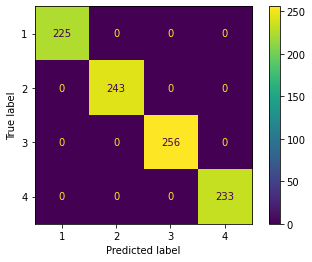

In [153]:
disp_model.plot() 

In [154]:
cm_clf_test=confusion_matrix(Y_test, clf_X_test_pred)

In [155]:
cm_clf_test

array([[225,   0,   0,   0],
       [  0, 243,   0,   0],
       [  0,   0, 256,   0],
       [  0,   0,   0, 233]], dtype=int64)

In [156]:
disp_clf = ConfusionMatrixDisplay(confusion_matrix=cm_clf_test, display_labels=model.classes_)

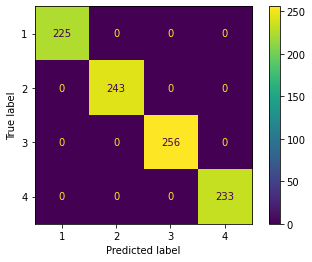

In [157]:
disp_clf.plot() 

In [158]:
cm_knn_test=confusion_matrix(Y_test, knn_X_test_pred)

In [159]:
cm_knn_test

array([[225,   0,   0,   0],
       [  0, 243,   0,   0],
       [  0,   0, 256,   0],
       [  0,   0,   0, 233]], dtype=int64)

In [160]:
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn_test, display_labels=model.classes_)

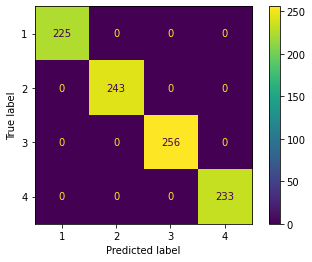

In [161]:
disp_knn.plot()

In [162]:
print(metrics.classification_report(Y_test, clf_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000       225
           2      1.000     1.000     1.000       243
           3      1.000     1.000     1.000       256
           4      1.000     1.000     1.000       233

    accuracy                          1.000       957
   macro avg      1.000     1.000     1.000       957
weighted avg      1.000     1.000     1.000       957



In [163]:
print(metrics.classification_report(Y_test, knn_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000       225
           2      1.000     1.000     1.000       243
           3      1.000     1.000     1.000       256
           4      1.000     1.000     1.000       233

    accuracy                          1.000       957
   macro avg      1.000     1.000     1.000       957
weighted avg      1.000     1.000     1.000       957



In [164]:
print(metrics.classification_report(Y_test, model_X_test_pred, digits=3))

              precision    recall  f1-score   support

           1      1.000     1.000     1.000       225
           2      1.000     1.000     1.000       243
           3      1.000     1.000     1.000       256
           4      1.000     1.000     1.000       233

    accuracy                          1.000       957
   macro avg      1.000     1.000     1.000       957
weighted avg      1.000     1.000     1.000       957



In [165]:
#model_cvp=cross_val_predict(model, X_test, Y_test, cv=3, method="predict")

In [166]:
#roc_auc_score(Y_test, model_pred_proba, multi_class='ovr')